<a href="https://colab.research.google.com/github/hafizatunabila/Computer-Vision-and-Deep-Learning/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Persiapan

In [2]:
import os
import time
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 2. Ambil dataset dari GitHub

In [3]:
GITHUB_USER = "hafizatunabila"
GITHUB_REPO = "Computer-Vision-and-Deep-Learning"

!rm -rf repo
!git clone -q https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git repo

In [4]:
!ls -lh repo

!rm -rf dataset
!unzip -q -o repo/dataset_patrol.zip -d dataset

!find dataset -maxdepth 2 -type f | head -20

total 26M
-rw-r--r-- 1 root root 26M Oct  3 05:50 dataset_patrol.zip


In [5]:
!find dataset -maxdepth 3 -type f | head -30

!find dataset -maxdepth 2 -type d

dataset
dataset/dataset_patrol
dataset/dataset_patrol/motorcycle
dataset/dataset_patrol/car


## 3. Siapkan data (train 80% / val 10% / test 10%)

In [6]:
norm = transforms.Normalize(
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225]
)

tf_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    norm
])

tf_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    norm
])

# Lokasi kelas yang sebenarnya
folder = "dataset/dataset_patrol"

# Dataset tanpa augmentasi untuk pembagian data
data_all = ImageFolder(folder, tf_eval)

print("Kelas:", data_all.classes)
print("Total foto:", len(data_all))

Kelas: ['car', 'motorcycle']
Total foto: 114


## 4. Fungsi pelatihan
- `feature`: hanya `fc` yang dilatih
- `partial`: `layer4` + `fc` yang dilatih
- `scratch`: tanpa bobot ImageNet, semua dilatih

In [7]:
def prediksi(model, loader):
    model.eval()
    asli, tebak = [], []
    with torch.no_grad():
        for x, y in loader:
            asli += y.tolist()
            tebak += model(x.to(device)).argmax(1).cpu().tolist()
    return asli, tebak


def latih(mode, epochs=10):
    torch.manual_seed(42)
    model = models.resnet18(weights=None if mode == "scratch" else "IMAGENET1K_V1")
    model.fc = nn.Linear(512, 2)

    # bagian yang dibekukan (tidak dilatih)
    beku = []
    if mode == "feature":
        beku = ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4"]
    if mode == "partial":
        beku = ["conv1", "bn1", "layer1", "layer2", "layer3"]
    for nama, bagian in model.named_children():
        if nama in beku:
            for p in bagian.parameters():
                p.requires_grad = False

    # optimizer
    if mode == "partial":
        optimizer = torch.optim.Adam([{"params": model.layer4.parameters(), "lr": 1e-4},
                                      {"params": model.fc.parameters(), "lr": 1e-3}])
    else:
        optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    model.to(device)

    train_acc, val_acc, terbaik = [], [], -1
    mulai = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        for nama, bagian in model.named_children():    # bagian beku tetap mode eval
            if nama in beku:
                bagian.eval()

        benar = 0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss_fn(out, y).backward()
            optimizer.step()
            benar += (out.argmax(1) == y).sum().item()
        scheduler.step()

        train_acc.append(benar / len(train_set))
        asli, tebak = prediksi(model, val_dl)
        val_acc.append(sum(a == t for a, t in zip(asli, tebak)) / len(asli))
        print(f"{mode} epoch {ep}/{epochs} | train {train_acc[-1]:.3f} | val {val_acc[-1]:.3f}")

        if val_acc[-1] > terbaik:                      # simpan bobot epoch terbaik
            terbaik = val_acc[-1]
            torch.save(model.state_dict(), mode + "_best.pt")
    waktu = round(time.time() - mulai)

    # epoch pertama yang val-nya >= 90%
    ep90 = None
    for i in range(len(val_acc)):
        if val_acc[i] >= 0.9:
            ep90 = i + 1
            break

    # ujian akhir di data test, pakai bobot terbaik
    model.load_state_dict(torch.load(mode + "_best.pt"))
    asli, tebak = prediksi(model, test_dl)
    test = sum(a == t for a, t in zip(asli, tebak)) / len(asli)
    print(f"Akurasi val terbaik: {terbaik:.3f} | Akurasi test: {test:.3f}")

    return {"mode": mode, "train_acc": train_acc, "val_acc": val_acc,
            "val_terbaik": terbaik, "ep90": ep90, "test": test, "waktu": waktu,
            "conf": confusion_matrix(asli, tebak, labels=[0, 1]).tolist()}

## 5. Latih tiga mode

### Mode feature

In [8]:
from torch.utils.data import Subset

# Dataset untuk training, menggunakan augmentasi
data_train = ImageFolder(folder, tf_train)

# Dataset untuk validasi dan testing, tanpa augmentasi
data_eval = ImageFolder(folder, tf_eval)

# Cek dataset
assert len(data_all) == 114, f"Jumlah foto harus 114, tapi ditemukan {len(data_all)}"
assert data_train.classes == data_eval.classes == ['car', 'motorcycle']

# Random split yang tetap sama setiap kali dijalankan
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(114, generator=generator).tolist()

# Pembagian:
# 92 foto untuk training
# 11 foto untuk validation
# 11 foto untuk testing

train_idx = indices[:92]
val_idx   = indices[92:103]
test_idx  = indices[103:114]

# Membuat dataset
train_set = Subset(data_train, train_idx)
val_set   = Subset(data_eval, val_idx)
test_set  = Subset(data_eval, test_idx)

print("========== JUMLAH DATA ==========")
print("Kelas       :", data_all.classes)
print("Total foto  :", len(data_all))
print("Train       :", len(train_set), "foto")
print("Validation  :", len(val_set), "foto")
print("Test        :", len(test_set), "foto")

========== JUMLAH DATA ==========
Kelas       : ['car', 'motorcycle']
Total foto  : 114
Train       : 92 foto
Validation  : 11 foto
Test        : 11 foto


In [9]:
from torch.utils.data import DataLoader

train_dl = DataLoader(
    train_set,
    batch_size=8,
    shuffle=True
)

val_dl = DataLoader(
    val_set,
    batch_size=8,
    shuffle=False
)

test_dl = DataLoader(
    test_set,
    batch_size=8,
    shuffle=False
)

print("========== JUMLAH BATCH ==========")
print("Train batch      :", len(train_dl))
print("Validation batch :", len(val_dl))
print("Test batch       :", len(test_dl))

========== JUMLAH BATCH ==========
Train batch      : 12
Validation batch : 2
Test batch       : 2


In [10]:
hasil_feature = latih("feature")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


feature epoch 1/10 | train 0.880 | val 1.000
feature epoch 2/10 | train 1.000 | val 1.000
feature epoch 3/10 | train 1.000 | val 1.000
feature epoch 4/10 | train 1.000 | val 1.000
feature epoch 5/10 | train 1.000 | val 1.000
feature epoch 6/10 | train 1.000 | val 1.000
feature epoch 7/10 | train 1.000 | val 1.000
feature epoch 8/10 | train 1.000 | val 1.000
feature epoch 9/10 | train 1.000 | val 1.000
feature epoch 10/10 | train 1.000 | val 1.000
Akurasi val terbaik: 1.000 | Akurasi test: 1.000


### Mode partial

In [11]:
hasil_partial = latih("partial")

partial epoch 1/10 | train 0.848 | val 1.000
partial epoch 2/10 | train 1.000 | val 1.000
partial epoch 3/10 | train 1.000 | val 1.000
partial epoch 4/10 | train 1.000 | val 1.000
partial epoch 5/10 | train 1.000 | val 1.000
partial epoch 6/10 | train 0.989 | val 1.000
partial epoch 7/10 | train 1.000 | val 1.000
partial epoch 8/10 | train 1.000 | val 1.000
partial epoch 9/10 | train 1.000 | val 1.000
partial epoch 10/10 | train 1.000 | val 1.000
Akurasi val terbaik: 1.000 | Akurasi test: 1.000


### Mode scratch

In [12]:
hasil_scratch = latih("scratch")

scratch epoch 1/10 | train 0.620 | val 0.909
scratch epoch 2/10 | train 0.598 | val 0.727
scratch epoch 3/10 | train 0.761 | val 0.636
scratch epoch 4/10 | train 0.804 | val 0.818
scratch epoch 5/10 | train 0.772 | val 0.364
scratch epoch 6/10 | train 0.783 | val 0.818
scratch epoch 7/10 | train 0.848 | val 0.727
scratch epoch 8/10 | train 0.880 | val 0.727
scratch epoch 9/10 | train 0.880 | val 0.727
scratch epoch 10/10 | train 0.870 | val 0.727
Akurasi val terbaik: 0.909 | Akurasi test: 0.545


## 6. Tabel hasil

In [13]:
hasil = [hasil_feature, hasil_partial, hasil_scratch]

tabel = pd.DataFrame(hasil)[["mode", "val_terbaik", "ep90", "test", "waktu"]]
tabel.columns = ["Mode", "Akurasi val terbaik", "Epoch pertama val >= 90%", "Akurasi test", "Waktu latih (s)"]
tabel

,Mode,Akurasi val terbaik,Epoch pertama val >= 90%,Akurasi test,Waktu latih (s)
0,feature,1.000000,1,1.000000,125
1,partial,1.000000,1,1.000000,160
2,scratch,0.909091,1,0.545455,295


## 7. Grafik akurasi per epoch

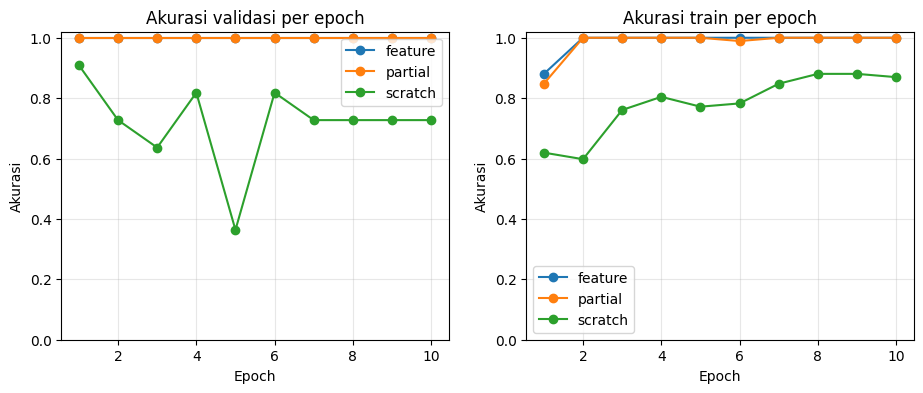

In [18]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
for h in hasil:
    plt.plot(range(1, len(h["val_acc"]) + 1), h["val_acc"], marker="o", label=h["mode"])
plt.title("Akurasi validasi per epoch")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.legend()
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for h in hasil:
    plt.plot(range(1, len(h["train_acc"]) + 1), h["train_acc"], marker="o", label=h["mode"])
plt.title("Akurasi train per epoch")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.legend()
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)

plt.show()

## 8. Latensi ResNet-18 (diukur di CPU, satu foto)

In [15]:
model = models.resnet18().eval()
foto = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    for i in range(20):
        model(foto)
    mulai = time.time()
    for i in range(100):
        model(foto)
    selesai = time.time()

ms = (selesai - mulai) / 100 * 1000
print(f"ResNet-18: {ms:.1f} ms per foto ({1000 / ms:.0f} foto/detik) di CPU")

ResNet-18: 94.2 ms per foto (11 foto/detik) di CPU


## 9. Confusion matrix (data test)

In [16]:
kelas = data_eval.classes

for h in hasil:
    print("Mode", h["mode"], "- baris = kelas asli, kolom = tebakan, urutan", kelas)
    for nama, baris in zip(kelas, h["conf"]):
        print(f"  {nama:8s} {baris}")
    print()

Mode feature - baris = kelas asli, kolom = tebakan, urutan ['car', 'motorcycle']
  car      [4, 0]
  motorcycle [0, 7]

Mode partial - baris = kelas asli, kolom = tebakan, urutan ['car', 'motorcycle']
  car      [4, 0]
  motorcycle [0, 7]

Mode scratch - baris = kelas asli, kolom = tebakan, urutan ['car', 'motorcycle']
  car      [4, 0]
  motorcycle [5, 2]

